# MMC Chatbot — MEAL Feedback EDA

Exploratory data analysis of `Base de datos MEAL Sami_060526.xlsx` (~78 post-interaction feedback records).

**What is this?** *Sami* is a WhatsApp chatbot that supports migrants in Colombia. After each interaction, users are invited to give feedback. *MEAL* stands for **Monitoring, Evaluation, Accountability and Learning** — the humanitarian-sector practice of systematically collecting feedback to check whether a service is actually helping the people it's meant to serve. This notebook turns that raw feedback into a picture of how Sami is doing.

**The story this notebook tells.** We follow the feedback from raw data to insight:

1. **How much feedback do we have, and can we trust it?** (Sections 1–2) — volume, completeness, and how representative it is.
2. **Are users satisfied, and would they recommend Sami?** (Sections 3–4) — the core satisfaction signals.
3. **How did they find Sami, and what do they say in their own words?** (Sections 5–6) — reach and qualitative themes.
4. **Is the service improving as it matures?** (Section 7) — trends over time.

---

### How to read this notebook

Every section opens with a plain-language summary — **What this shows** and **Why it matters** — that needs no technical background. Where a chart or calculation involves a non-obvious choice (a scale, a smoothing window, a data-cleaning rule), a short **Technical note** explains it for readers who want the detail. You can follow the narrative top-to-bottom without reading any code. The setup cells below (imports and plot styling) are collapsed by default — they carry no analysis.

## Setup

In [1]:
# Imports. Collapsed on purpose -- no analysis here.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from collections import Counter
from wordcloud import WordCloud

In [2]:
# Plot styling & colour system (Diversa brand). Collapsed -- no analysis here.
#   BLUE_SEQ : brand blue ramp light->dark (ordered magnitude: ratings)
#   CAT      : categorical hues, fixed order, alternating brand blue & earth
#   ink/surface neutrals keep text and background out of the colour story.
BLUE_SEQ = ['#DFE3F0', '#C5CFEB', '#A2B4E5', '#90A6E1', '#7692DC', '#6D8BDB']
EARTH    = ['#e0dedb', '#d0d2a5', '#b5b797', '#8f8f78', '#6e824a']
CAT = ['#6D8BDB', '#8f8f78', '#A2B4E5', '#6e824a', '#7692DC',
       '#d0d2a5', '#90A6E1', '#b5b797', '#C5CFEB', '#e0dedb']
PRIMARY  = '#6D8BDB'                                 # single-series brand blue

INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'  # text inks
GRID, SURFACE    = '#e6e5df', '#ffffff'             # grid / background

def cat_colors(n):
    """First n categorical hues, fixed order (never cycled)."""
    return CAT[:n]

def seq_colors(n):
    """n evenly-spaced steps of the blue ramp, light->dark."""
    if n <= 1:
        return [BLUE_SEQ[2]]
    idx = np.linspace(0, len(BLUE_SEQ) - 1, n).round().astype(int)
    return [BLUE_SEQ[i] for i in idx]

def pct_count_autopct(values, min_pct=3.0):
    """Pie label 'xx.x%\\n(n)'; blank for slices under min_pct to avoid clutter."""
    total = float(sum(values))
    def _fmt(pct):
        if pct < min_pct:
            return ''
        return f"{pct:.1f}%\n({int(round(pct/100*total))})"
    return _fmt

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': MUTED, 'axes.linewidth': 0.8,
    'text.color': INK, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'semibold', 'axes.titlelocation': 'left',
    'axes.titlepad': 10,
    'xtick.color': INK2, 'ytick.color': INK2,
    'axes.grid': False, 'grid.color': GRID, 'grid.linewidth': 0.7,
    'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110, 'font.size': 10,
})

## 1. Data Load

**What this shows:** The two source spreadsheets we work with, and the cleaning we apply before any analysis. The **MEAL feedback form** (~78 post-interaction survey responses) is the focus of this notebook; the **responses database** (~940 chatbot interaction records) is loaded only to put the feedback in context (e.g. what share of users actually responded).

**Why it matters:** Raw survey exports are messy — banner rows, blank lines, and long Spanish question text as column names. Getting to a clean table first means every chart downstream is built on the same trustworthy foundation.

> **Technical note — the dataset is small (n ≈ 78).** Every chart here should be read as *directional*, not statistically conclusive. A handful of responses can move a percentage substantially, so we favour showing raw counts alongside percentages and avoid over-interpreting small differences.

> **Technical note — loading.** The sheet has two banner rows above the real headers, so we read with `header=2` and drop fully-blank rows. Columns are renamed to short, code-friendly labels. The Spanish Likert ratings are mapped to a **1–5 numeric scale** (`Nada útil`=1 … `Muy útil`=5) in `rating_num` — this is what lets us average the score and plot its trend over time in Section 7.

In [3]:
# Source spreadsheets: MEAL feedback form and chatbot interaction log
MEAL_PATH = '../data_&_docs/MMC_MEAL_Group_Title_1783087939.xlsx'
RESP_PATH = '../data_&_docs/MMC_bot_responses_Grupo_nuevo_1783087815.xlsx'

# header=2: the sheet has two banner rows above the real column headers
meal = pd.read_excel(MEAL_PATH, sheet_name='mmc-meal', header=2)
meal = meal.dropna(how='all').reset_index(drop=True)  # drop blank rows left by the banner

# Replace the long Spanish question text with short, code-friendly column names
meal.columns = [
    'Name', 'Timestamp',
    'usefulness_rating', 'would_recommend',
    'recommendation_text', 'discovery_channel', 'discovery_other',
]
meal['Timestamp'] = pd.to_datetime(meal['Timestamp'], errors='coerce')

# Map the Spanish Likert labels to a 1-5 numeric scale so we can average / trend
RATING_MAP = {
    'Muy útil': 5, 'Útil': 4,
    'Medianamente útil': 3, 'Poco útil': 2, 'Nada útil': 1,
}
meal['rating_num'] = meal['usefulness_rating'].map(RATING_MAP)

print(f"MEAL records: {len(meal)}")
meal.head()

MEAL records: 78


,Name,Timestamp,usefulness_rating,would_recommend,recommendation_text,discovery_channel,discovery_other,rating_num
0,whatsapp:+56929572884,2026-03-26 00:47:35.583000+00:00,Muy útil,Sí,Excelente,Recomendación de una ONG,NaN,5
1,whatsapp:+573113165608,2026-03-26 10:12:14.030000+00:00,Nada útil,Prefiero no responder,"Ayuda, no se cómo activar mi línea nueva Tigo ...",Otro,Redes sociales,1
2,whatsapp:+16462943119,2026-03-26 16:06:16.380000+00:00,Nada útil,Prefiero no responder,No recibí ninguna información.,Redes sociales,NaN,1
3,whatsapp:+573192311911,2026-03-27 03:36:50.975000+00:00,Medianamente útil,Prefiero no responder,No,Recomendación de una ONG,NaN,3
4,whatsapp:+16462943119,2026-03-27 11:47:53.350000+00:00,Nada útil,Prefiero no responder,No recibí información,Otro,Otro,1


## 2. Data Quality

**What this shows:** How complete the feedback data is (which fields have gaps), and what share of all chatbot users actually filled out the feedback form — the **MEAL response rate**.

**Why it matters:** Two reliability checks before we draw any conclusions. First, gaps matter because charts silently drop empty rows — knowing where the gaps are tells us which questions to read with caution. Second, the response rate tells us how *representative* the feedback is: if only a small fraction of users respond, satisfaction scores reflect that vocal minority, not necessarily everyone.

> **Technical note.** The chart shows the **share of records missing** each field (% of all responses). The response rate is computed as unique MEAL respondents ÷ unique users in the full responses database. Because both numbers are small, treat the rate as a rough order of magnitude, not a precise figure.

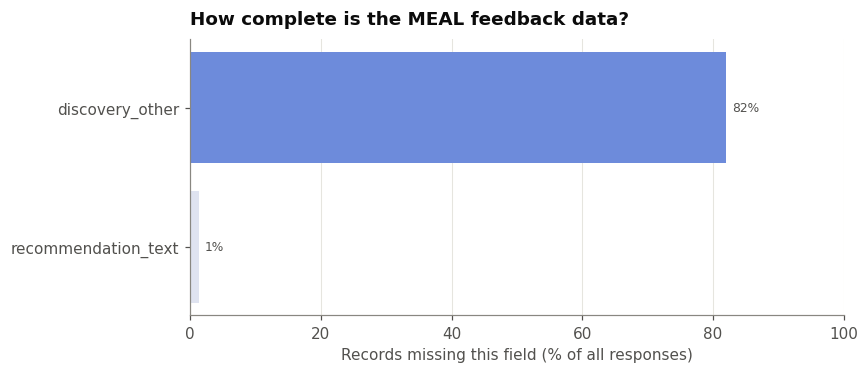

Total chatbot users (responses DB): 918
MEAL respondents:                   69
MEAL response rate:                 7.5%


In [4]:
# Share of records missing each field (% of all responses), high -> low.
miss = meal.isnull().mean()
miss = miss[miss > 0].sort_values()

fig, ax = plt.subplots(figsize=(8, 3.5))
if len(miss):
    bars = ax.barh(miss.index, miss.values * 100, color=seq_colors(len(miss)))
    ax.bar_label(bars, labels=[f"{v*100:.0f}%" for v in miss.values],
                 padding=4, fontsize=8, color=INK2)
else:
    ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=ax.transAxes)
ax.set_xlim(0, 100)
ax.set_xlabel('Records missing this field (% of all responses)')
ax.grid(True, axis='x')
ax.set_title('How complete is the MEAL feedback data?')
plt.tight_layout()
plt.show()

# How many chatbot users left MEAL feedback? (response rate)
resp_df = pd.read_excel(RESP_PATH, sheet_name='mmc bot - responses', header=2)
resp_df = resp_df.dropna(how='all').reset_index(drop=True)
total_users = resp_df['Name'].nunique()
meal_users = meal['Name'].nunique()
print(f"Total chatbot users (responses DB): {total_users}")
print(f"MEAL respondents:                   {meal_users}")
print(f"MEAL response rate:                 {meal_users / total_users * 100:.1f}%")

## 3. Usefulness Rating

**What this shows:** The headline satisfaction number. Users rated how useful Sami was on a 5-point scale from *Nada útil* (not useful at all) to *Muy útil* (very useful). The bar chart shows how many people chose each level, and the average score is printed on the chart.

**Why it matters:** This is the single most direct measure of whether Sami is helping. The shape of the distribution matters as much as the average — satisfaction clustered at the top is a very different story from opinions split between "very useful" and "not useful at all," even if the two produce a similar mean.

> **Technical note.** Bars are ordered low→high (not by frequency) and shaded with a light-to-dark blue ramp so the eye reads the rating *scale*, not just the counts. The mean is computed from the 1–5 `rating_num` mapping defined in Section 1 and annotated directly on the axes.

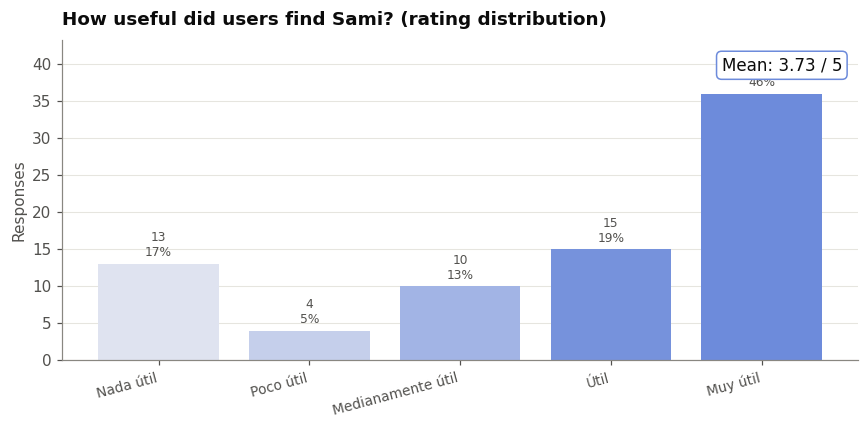

In [5]:
# Order categories least -> most useful (an ordinal scale, not by frequency).
rating_order = ['Nada útil', 'Poco útil', 'Medianamente útil', 'Útil', 'Muy útil']
rc = meal['usefulness_rating'].value_counts().reindex(rating_order, fill_value=0)
total = rc.sum()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(rc)), rc.values, color=seq_colors(len(rc)))
ax.set_xticks(range(len(rc)))
ax.set_xticklabels(rc.index, rotation=15, ha='right', fontsize=9)
ax.bar_label(bars, labels=[f"{v}\n{v/total*100:.0f}%" for v in rc.values],
             padding=3, fontsize=8, color=INK2)
ax.set_ylabel('Responses')
ax.set_ylim(0, rc.max() * 1.2)
ax.grid(True, axis='y')
ax.set_title('How useful did users find Sami? (rating distribution)')

mean_r = meal['rating_num'].mean()
ax.text(0.98, 0.95, f'Mean: {mean_r:.2f} / 5', transform=ax.transAxes,
        ha='right', va='top', fontsize=11, color=INK,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=SURFACE, edgecolor=PRIMARY))
plt.tight_layout()
plt.show()

## 4. Would Recommend

**What this shows:** Whether users would recommend Sami to someone else in a similar situation, split into *Sí* (yes), *No*, and *Prefiero no responder* (prefer not to answer).

**Why it matters:** This is a word-of-mouth signal, and it complements the usefulness rating rather than repeating it — someone can find a tool moderately useful but still not recommend it, or vice versa. For a service that reaches migrant communities largely through trust networks, a high "Sí" share points to real potential for organic growth.

> **Technical note.** This is an NPS-style proxy, not a true Net Promoter Score (there's no 0–10 scale). Each slice is labelled with its share **and** exact count, since with a small sample a percentage alone can be misleading.

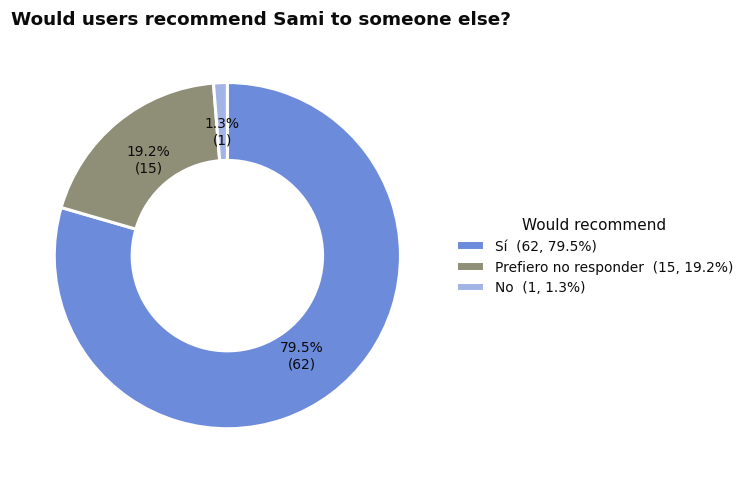

would_recommend
Sí                       62
Prefiero no responder    15
No                        1


In [6]:
# Would users recommend Sami? Share + count per slice.
rec = meal['would_recommend'].value_counts()
fig, ax = plt.subplots(figsize=(6.5, 4.5))
wedges, _t, _a = ax.pie(
    rec.values, colors=cat_colors(len(rec)),
    autopct=pct_count_autopct(rec.values, min_pct=1.0), pctdistance=0.72,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor=SURFACE, linewidth=2),
    textprops=dict(fontsize=9, color=INK))
ax.legend(wedges, [f"{k}  ({v}, {v/rec.sum()*100:.1f}%)" for k, v in rec.items()],
          title='Would recommend', loc='center left', bbox_to_anchor=(1.0, 0.5),
          fontsize=9, frameon=False)
ax.set_title('Would users recommend Sami to someone else?')
plt.tight_layout()
plt.show()
print(rec.to_string())

## 5. Discovery Channel

**What this shows:** How users first heard about Sami — for example through a partner NGO, social media, or word of mouth.

**Why it matters:** Discovery channels tell outreach teams where their effort is actually paying off. There's also a risk angle: if nearly everyone arrives through a single channel (say, one partner organization), the service is dependent on that one relationship. A more even spread signals broader, more resilient reach.

> **Technical note.** Exact counts are labelled on each bar. The "Otro" (Other) free-text answers are captured separately in `discovery_other`; this chart shows the structured channel choice.

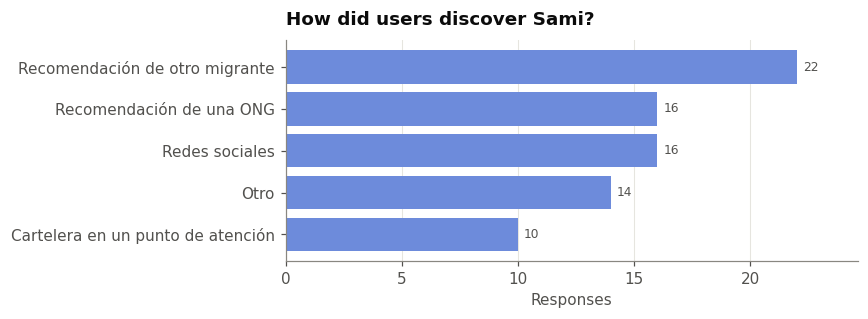

In [7]:
# How did users discover Sami?
disc = meal['discovery_channel'].value_counts()
fig, ax = plt.subplots(figsize=(8, max(3, len(disc) * 0.5)))
bars = ax.barh(disc.index[::-1], disc.values[::-1], color=PRIMARY)
ax.bar_label(bars, padding=4, fontsize=8, color=INK2)
ax.set_xlabel('Responses')
ax.set_xlim(0, disc.max() * 1.12)
ax.grid(True, axis='x')
ax.set_title('How did users discover Sami?')
plt.tight_layout()
plt.show()

## 6. Open Text — What Users Recommend

**What this shows:** Users' own words. The feedback form asks what they would recommend improving about Sami. We look at this two ways: a **length distribution** (how much people wrote) and a **word cloud** (which words come up most often).

**Why it matters:** Numbers tell us *whether* people are satisfied; the open text starts to tell us *why*, and surfaces concrete improvement ideas. How much someone writes is itself a rough signal of engagement. The word cloud lets us spot recurring themes across all responses at a glance.

> **Technical note.** Length is measured in characters as an engagement proxy, with the mean marked. For the word cloud, text is lower-cased, stripped of punctuation, and filtered against a Spanish stop-word list plus a minimum length, so only meaningful terms remain. With so few responses, the word cloud is a qualitative prompt for closer reading — not a quantitative ranking.

### 6.1 Length of recommendations

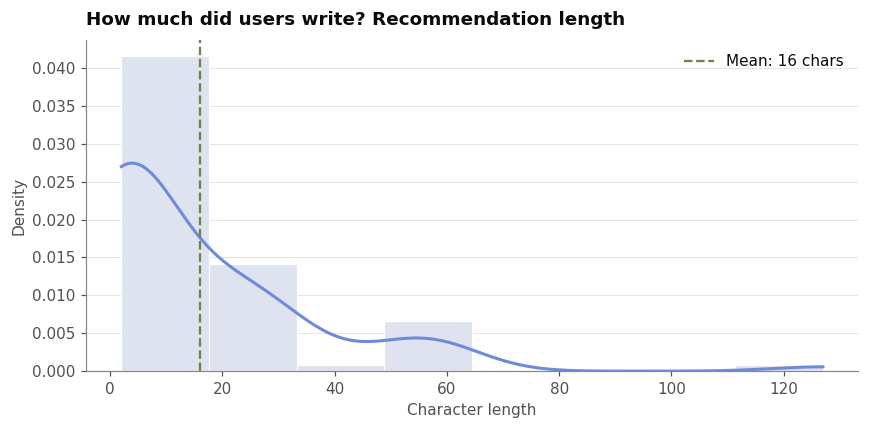

In [8]:
# Character length of each free-text recommendation, as an engagement proxy,
# with a smoothed density curve over the histogram.
rec_text = meal['recommendation_text'].dropna()
lengths = rec_text.str.len()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=8, density=True, color=BLUE_SEQ[0],
        edgecolor=SURFACE, linewidth=0.8)
if lengths.nunique() > 1:
    xs = np.linspace(lengths.min(), lengths.max(), 200)
    ax.plot(xs, gaussian_kde(lengths)(xs), color=PRIMARY, linewidth=2)
ax.axvline(lengths.mean(), color='#6e824a', linestyle='--', linewidth=1.5,
           label=f'Mean: {lengths.mean():.0f} chars')
ax.legend(frameon=False)
ax.set_xlabel('Character length')
ax.set_ylabel('Density')
ax.grid(True, axis='y')
ax.set_title('How much did users write? Recommendation length')
plt.tight_layout()
plt.show()

### 6.2 Word cloud

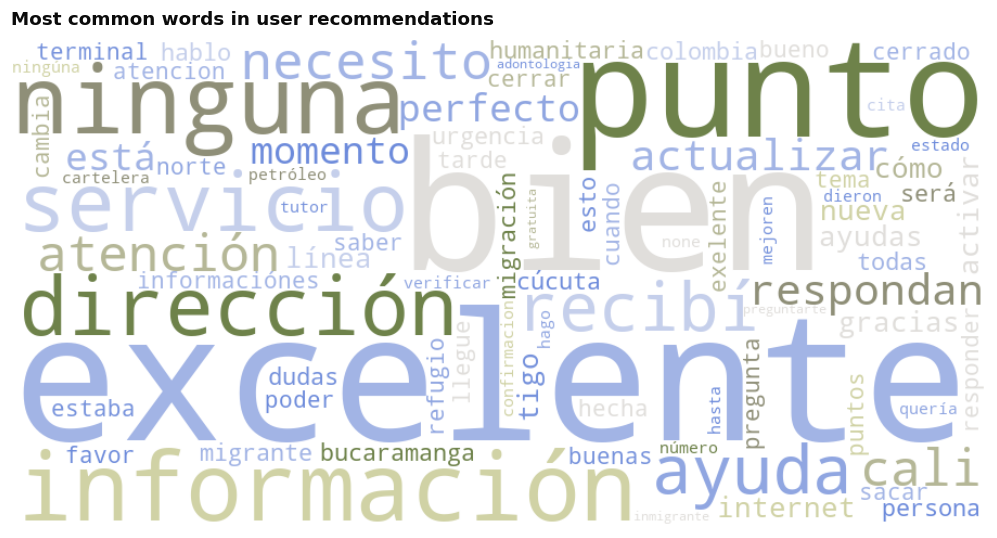

In [9]:
# Common Spanish stopwords to exclude so the cloud highlights meaningful themes.
ES_STOPWORDS = {
    'de', 'la', 'el', 'en', 'y', 'a', 'que', 'no', 'es', 'se', 'los', 'las',
    'con', 'por', 'un', 'una', 'para', 'más', 'del', 'al', 'lo', 'le', 'su',
    'me', 'mi', 'como', 'muy', 'pero', 'si', 'ya', 'este', 'esta', 'son', 'hay',
    'fue', 'ser', 'tiene', 'han', 'he', 'nos', 'sus', 'todo', 'también',
}
rec_text = meal['recommendation_text'].dropna()
all_words = ' '.join(rec_text.str.lower()).split()
words = [w.strip('.,;:!?()\"\'') for w in all_words
         if len(w) > 3 and w.strip('.,;:!?()\"\'') not in ES_STOPWORDS]
word_freq = Counter(words)

# Colour words from the categorical palette so the cloud matches the notebook.
def _brand_color_func(word, font_size, position, orientation, random_state, **kwargs):
    return CAT[random_state.randint(0, len(CAT) - 1)]

wc = WordCloud(width=900, height=450, background_color=SURFACE,
               color_func=_brand_color_func, prefer_horizontal=0.9
               ).generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most common words in user recommendations', fontsize=12)
plt.tight_layout()
plt.show()

## 7. MEAL Responses Over Time

**What this shows:** The feedback as a timeline instead of a snapshot. The left panel tracks the **running total of responses** since launch; the right panel plots **each usefulness rating on the day it was given**, with a smoothed trend line through them.

**Why it matters:** A single average hides whether things are getting better or worse. This is where we can see momentum: a steadily climbing total means the feedback loop is alive, while a rising (or falling) trend line shows whether users are growing more — or less — satisfied as Sami evolves.

> **Technical note.** The left panel is a daily count accumulated into a cumulative sum. The right panel's trend line is a **14-day rolling mean** (`min_periods=2`): each point averages the ratings from the surrounding two weeks, smoothing day-to-day noise. With ~78 points over weeks, read the trend's *direction*, not the exact value on any given day.

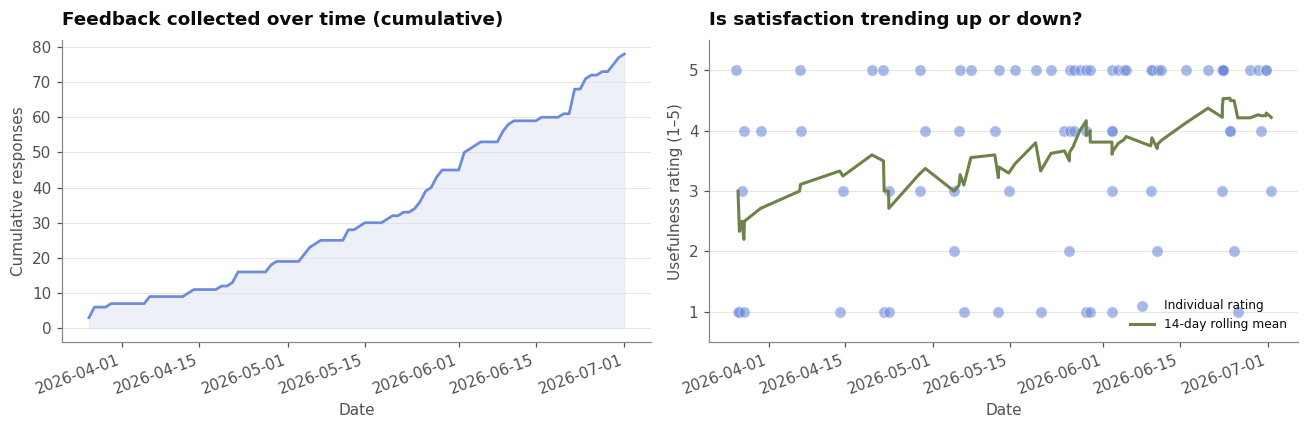

In [10]:
# Left: cumulative reach of the survey. Right: ratings over time + rolling mean.
timeline = meal.dropna(subset=['Timestamp']).set_index('Timestamp').resample('D').size()
cumulative = timeline.cumsum()

meal_sorted = meal.dropna(subset=['Timestamp', 'rating_num']).sort_values('Timestamp')
rolling_mean = meal_sorted.set_index('Timestamp')['rating_num'].rolling('14D', min_periods=2).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].fill_between(cumulative.index, cumulative.values, color=BLUE_SEQ[0], alpha=0.5)
axes[0].plot(cumulative.index, cumulative.values, color=PRIMARY, linewidth=1.8)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative responses')
axes[0].grid(True, axis='y')
axes[0].set_title('Feedback collected over time (cumulative)')

axes[1].scatter(meal_sorted['Timestamp'], meal_sorted['rating_num'],
                color=PRIMARY, alpha=0.6, s=55, edgecolors='white', linewidths=0.5,
                label='Individual rating')
axes[1].plot(rolling_mean.index, rolling_mean.values, color='#6e824a', linewidth=2,
             label='14-day rolling mean')
axes[1].set_ylim(0.5, 5.5)
axes[1].set_yticks([1, 2, 3, 4, 5])
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Usefulness rating (1–5)')
axes[1].grid(True, axis='y')
axes[1].legend(fontsize=8, frameon=False)
axes[1].set_title('Is satisfaction trending up or down?')

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()